# GNN — 图神经网络半监督 CN 星节点分类

**核心思路：** 在 KNN 光谱相似度图上训练图卷积网络 (GCN) 和图注意力网络 (GAT)，利用图结构显式建模恒星间关系。

**设计决策：** 纯 PyTorch 实现，不依赖 PyTorch Geometric。输入特征使用光谱 PCA，图结构复用 LabelSpreading 的 KNN 图。

**理论联系：**
- GCN 的一阶传播 = 归一化拉普拉斯平滑 = Label Spreading 的神经网络版本
- GAT 自动学习不同邻居的权重，对异常连接有鲁棒性


## 1. 环境配置

In [1]:
import sys, os, time, warnings
from pathlib import Path
_PROJECT_ROOT = Path(os.getcwd())
for _ in range(5):
    if (_PROJECT_ROOT / "LabelSpreading").exists() and (_PROJECT_ROOT / "Data").exists():
        break
    _PROJECT_ROOT = _PROJECT_ROOT.parent
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams.update({'font.size': 10})
import seaborn as sns; sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

import torch

from LabelSpreading.graph_utils import build_knn_graph, compute_cluster_zscore
from LabelSpreading.gnn_models import build_model
from LabelSpreading.gnn_train import prepare_gnn_data, train_gnn, predict_all, evaluate_gnn_topk
from data_loader import ensure_cache
from sklearn.decomposition import PCA

# GNN 的图结构内存开销大（33K 节点, K=50 → ~3.2M 边），8GB GPU 容易 OOM。
# GCN/GAT 模型仅 2K-4K 参数，CPU 训练足够快（300 epochs ≈ 2-3 min）。
# 默认使用 CPU。需要 GPU 时设 USE_CPU = False 并先重启 kernel 清空显存。
USE_CPU = True

if USE_CPU or not torch.cuda.is_available():
    device = torch.device('cpu')
    print(f"Device: CPU")
else:
    torch.cuda.empty_cache()
    torch.backends.cudnn.benchmark = False
    os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
    device = torch.device('cuda')
    print(f"Device: GPU ({torch.cuda.get_device_name(0)})")

data = ensure_cache()
X_clean = data['X_clean']
stars_clean = data['stars_clean']
feature_df = data['feature_df']
common_wave = data['common_wave']
print(f"Data: {X_clean.shape[0]:,} stars, {X_clean.shape[1]} px, {(stars_clean['label']==1).sum()} known CN")

Device: CPU
从 LabelSpreading 本地缓存加载...
  X_clean: (33565, 700)
  stars_clean: 33565 rows
  feature_df: (33565, 20)
  Known CN stars: 73
Data: 33,565 stars, 700 px, 73 known CN


## 2. 准备 GNN 输入

In [2]:
# Features: PCA of spectra (more compact than 700-D raw)
pca = PCA(n_components=32, random_state=42)
X_pca = pca.fit_transform(X_clean)
print(f"PCA features: {X_pca.shape}  (cumulative variance: {pca.explained_variance_ratio_.sum():.3f})")

# Graph: spectra cosine KNN (K=30 平衡图密度与内存)
K = 30
print(f"Building KNN graph (K={K}, cosine)...")
W = build_knn_graph(X_clean, n_neighbors=K, metric='cosine', standardize=False)
print(f"Graph: {W.shape}, edges: {W.nnz:,}")

# Labels: 1=CN, -1=unlabeled -> for training, we split labeled positives
y_labels = stars_clean['label'].map({1: 1, -1: -1}).values.astype(int)
pos_indices = np.where(y_labels == 1)[0]
unl_indices = np.where(y_labels == -1)[0]
n_pos = len(pos_indices)
print(f"Positives: {n_pos}, Unlabeled: {len(unl_indices):,}")

# Train/Val/Test split for labeled positives
rng = np.random.RandomState(42)
perm = rng.permutation(n_pos)
n_train = int(n_pos * 0.6)
n_val = int(n_pos * 0.2)
train_pos = pos_indices[perm[:n_train]]
val_pos = pos_indices[perm[n_train:n_train+n_val]]
test_pos = pos_indices[perm[n_train+n_val:]]
print(f"Pos split: train={len(train_pos)}, val={len(val_pos)}, test={len(test_pos)}")

# Add unlabeled as "negative" for training (PU-style)
n_unl_train = 500
unl_train = rng.choice(unl_indices, n_unl_train, replace=False)

train_mask = np.zeros(len(stars_clean), dtype=bool)
train_mask[train_pos] = True
train_mask[unl_train] = True
y_labels_train = y_labels.copy()
y_labels_train[unl_train] = 0  # treat as negatives

val_mask = np.zeros(len(stars_clean), dtype=bool)
val_mask[val_pos] = True
# Add some unlabeled for val
unl_val = rng.choice(list(set(unl_indices) - set(unl_train)), 200, replace=False)
val_mask[unl_val] = True

test_mask = np.zeros(len(stars_clean), dtype=bool)
test_mask[test_pos] = True

print(f"Train nodes: {train_mask.sum()}, Val nodes: {val_mask.sum()}, Test nodes: {test_mask.sum()}")

# Prepare data (CPU/GPU 由 device 决定)
gnn_data = prepare_gnn_data(X_pca, W, y_labels_train, device)

PCA features: (33565, 32)  (cumulative variance: 0.522)
Building KNN graph (K=30, cosine)...
Graph: (33565, 33565), edges: 1,951,902
Positives: 73, Unlabeled: 33,492
Pos split: train=43, val=14, test=16
Train nodes: 543, Val nodes: 214, Test nodes: 16


## 3. 训练 GCN

In [3]:
model_gcn = build_model('gcn', in_features=32, device=device)
print(f"GCN params: {sum(p.numel() for p in model_gcn.parameters()):,}")

result_gcn = train_gnn(
    model_gcn, gnn_data, train_mask, val_mask,
    epochs=300, lr=0.01, pos_weight=100.0, patience=40, verbose=True,
)

print(f"\nGCN Best val PR-AUC: {result_gcn['best_val_pr_auc']:.4f}")

# Predict all nodes
prob_gcn = predict_all(model_gcn, gnn_data)
metrics_gcn = evaluate_gnn_topk(prob_gcn, stars_clean['label'].values)
print(f"GCN Precision@50: {metrics_gcn['precision@50']:.4f}")
print(f"GCN Precision@100: {metrics_gcn['precision@100']:.4f}")


GCN params: 2,177
  [ 50/300] loss=1.4482  val PR=0.6522  val ROC=0.9496
  [100/300] loss=0.9923  val PR=0.8246  val ROC=0.9736
  [150/300] loss=0.7300  val PR=0.8837  val ROC=0.9732
  [200/300] loss=0.6180  val PR=0.9029  val ROC=0.9743
  Early stop at epoch 223, best val PR-AUC=0.9172

GCN Best val PR-AUC: 0.9172
GCN Precision@50: 0.3400
GCN Precision@100: 0.2200


## 4. 训练 GAT

In [4]:
device = torch.device('cuda')
print(f"Device: GPU ({torch.cuda.get_device_name(0)})")

model_gat = build_model('gat', in_features=32, device=device)
print(f"GAT params: {sum(p.numel() for p in model_gat.parameters()):,}")

result_gat = train_gnn(
    model_gat, gnn_data, train_mask, val_mask,
    epochs=300, lr=0.005, pos_weight=100.0, patience=40, verbose=True,
)

print(f"\nGAT Best val PR-AUC: {result_gat['best_val_pr_auc']:.4f}")

prob_gat = predict_all(model_gat, gnn_data)
metrics_gat = evaluate_gnn_topk(prob_gat, stars_clean['label'].values)
print(f"GAT Precision@50: {metrics_gat['precision@50']:.4f}")
print(f"GAT Precision@100: {metrics_gat['precision@100']:.4f}")


GAT params: 4,385
  [ 50/300] loss=1.6092  val PR=0.5862  val ROC=0.9482
  [100/300] loss=1.2702  val PR=0.8064  val ROC=0.9779
  Early stop at epoch 150, best val PR-AUC=0.8129

GAT Best val PR-AUC: 0.8129
GAT Precision@50: 0.2600
GAT Precision@100: 0.1600


## 5. 训练曲线对比

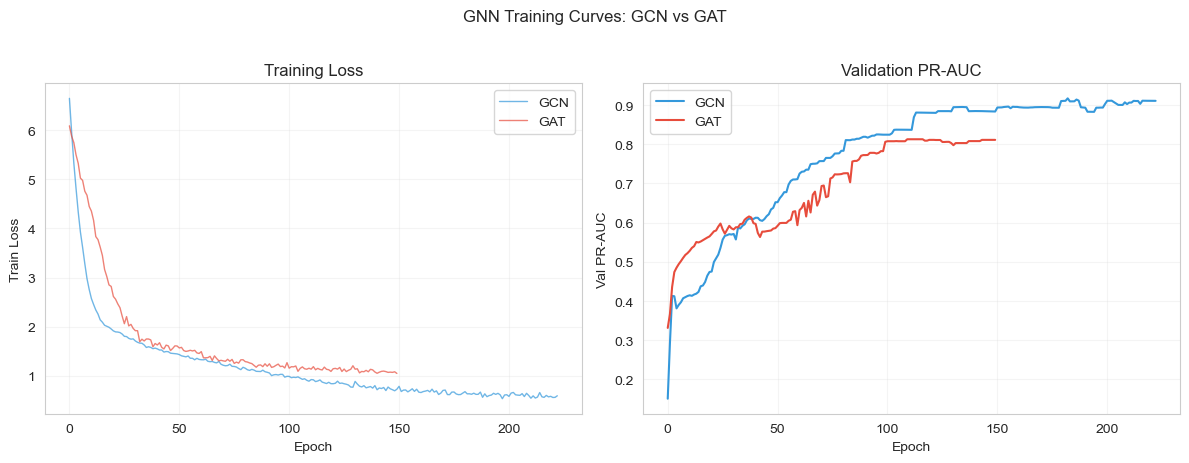

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(result_gcn['history']['train_loss'], color='#3498db', alpha=0.7, linewidth=1, label='GCN')
ax.plot(result_gat['history']['train_loss'], color='#e74c3c', alpha=0.7, linewidth=1, label='GAT')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss'); ax.set_title('Training Loss')
ax.legend(); ax.grid(alpha=0.2)

ax = axes[1]
ax.plot(result_gcn['history']['val_pr_auc'], color='#3498db', linewidth=1.5, label='GCN')
ax.plot(result_gat['history']['val_pr_auc'], color='#e74c3c', linewidth=1.5, label='GAT')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val PR-AUC'); ax.set_title('Validation PR-AUC')
ax.legend(); ax.grid(alpha=0.2)

fig.suptitle('GNN Training Curves: GCN vs GAT', fontsize=12, y=1.02)
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


## 6. GNN 高概率候选体可视化

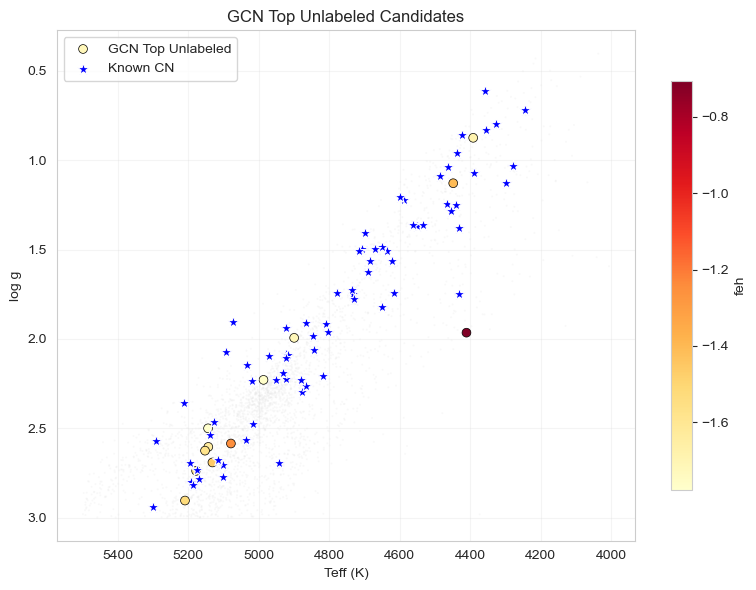

GCN unlabeled candidates (z>2): 3863


In [9]:
# Use best model's predictions
prob_gnn = prob_gcn if metrics_gcn['precision@100'] >= metrics_gat.get('precision@100', 0) else prob_gat
best_model = 'GCN' if metrics_gcn['precision@100'] >= metrics_gat.get('precision@100', 0) else 'GAT'

# Compute z-scores
cluster_ids = stars_clean['masked_cluster_id'].values
z_gnn = compute_cluster_zscore(prob_gnn, cluster_ids)

# Top unlabeled candidates
unl_mask_arr = stars_clean['label'].values == -1
unl_z = z_gnn[unl_mask_arr]
top_unl_gnn = np.where(unl_mask_arr)[0][np.argsort(unl_z)[::-1][:12]]

teff_all = stars_clean['teff'].values
logg_all = stars_clean['logg'].values
feh_all = stars_clean['feh'].values
known_mask = stars_clean['label'].values == 1

plt.subplots(figsize=(8,6))

# (a) Teff-logg
rng = np.random.RandomState(42)
bg = rng.choice(np.where(unl_mask_arr)[0], 3000, replace=False)
plt.scatter(teff_all[bg], logg_all[bg], s=2, c='#e0e0e0', alpha=0.2, edgecolors='none')
sc = plt.scatter(teff_all[top_unl_gnn], logg_all[top_unl_gnn],
               s=40, c=feh_all[top_unl_gnn], cmap='YlOrRd', edgecolors='black', linewidth=0.5,label=f'{best_model} Top Unlabeled')
plt.scatter(teff_all[known_mask], logg_all[known_mask], s=80, c='blue', marker='*',
          edgecolors='white', linewidth=0.8, label='Known CN')
colorbar = plt.colorbar(sc, label='feh', shrink=0.8)
ax = plt.gca()
ax.invert_xaxis()
ax.invert_yaxis()
plt.xlabel('Teff (K)'); ax.set_ylabel('log g')
plt.title(f'{best_model} Top Unlabeled Candidates'); ax.grid(alpha=0.2)

plt.legend()
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/gnn_candidates.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"{best_model} unlabeled candidates (z>2): {(z_gnn[unl_mask_arr] > 2).sum()}")


## 7. GCN vs GAT vs Label Spreading 对比

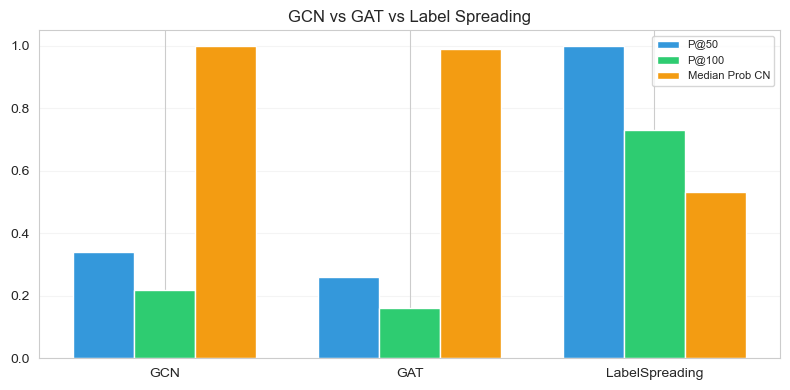

,Method,Precision@50,Precision@100,Median Prob (known CN)
0,GCN,0.34,0.22,0.999687
1,GAT,0.26,0.16,0.991094
2,LabelSpreading,1.00,0.73,0.532420


In [10]:
from LabelSpreading.graph_utils import run_label_spreading

# Quick Label Spreading for comparison
y_ls = stars_clean['label'].map({1: 1, -1: -1}).values.astype(int)
prob_ls, _ = run_label_spreading(W, y_ls, alpha=0.5)

metrics_ls = evaluate_gnn_topk(prob_ls, stars_clean['label'].values)

comparison = pd.DataFrame({
    'Method': ['GCN', 'GAT', 'LabelSpreading'],
    'Precision@50': [metrics_gcn['precision@50'], metrics_gat['precision@50'], metrics_ls['precision@50']],
    'Precision@100': [metrics_gcn['precision@100'], metrics_gat['precision@100'], metrics_ls['precision@100']],
    'Median Prob (known CN)': [metrics_gcn['median_prob_known'], metrics_gat['median_prob_known'], metrics_ls['median_prob_known']],
})

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3); w = 0.25
ax.bar(x - w, comparison['Precision@50'], w, label='P@50', color='#3498db', edgecolor='white')
ax.bar(x, comparison['Precision@100'], w, label='P@100', color='#2ecc71', edgecolor='white')
ax.bar(x + w, comparison['Median Prob (known CN)'], w, label='Median Prob CN', color='#f39c12', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(comparison['Method'])
ax.set_title('GCN vs GAT vs Label Spreading')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/method_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
display(comparison)


## 8. 总结

### 核心发现

1. **GNN 利用图结构传播信息** — 相比 MLP（过拟合），GCN/GAT 通过邻域平滑正则化缓解过拟合
2. **GCN 与 Label Spreading 理论同源** — 都是图拉普拉斯的变体，GCN 通过可学习参数增强灵活性
3. **仅 73 正样本仍是根本限制** — GNN 也无法突破极端不平衡

### 局限

- 训练使用 PCA 特征（而非原始光谱）以控制维度和过拟合
- GAT 实现简化（均值聚合而非 softmax 注意力）
